In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
raisin_data = pd.read_csv('/content/Raisin_Dataset.csv')
raisin_data.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [ ]:
raisin_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             900 non-null    int64  
 1   MajorAxisLength  900 non-null    float64
 2   MinorAxisLength  900 non-null    float64
 3   Eccentricity     900 non-null    float64
 4   ConvexArea       900 non-null    int64  
 5   Extent           900 non-null    float64
 6   Perimeter        900 non-null    float64
 7   Class            900 non-null    object 
dtypes: float64(5), int64(2), object(1)
memory usage: 56.4+ KB


In [ ]:
raisin_data['Class'].value_counts()

,count
Class,
Kecimen,450
Besni,450


In [ ]:
raisin_data.isnull().sum()

,0
Area,0
MajorAxisLength,0
MinorAxisLength,0
Eccentricity,0
ConvexArea,0
Extent,0
Perimeter,0
Class,0


In [ ]:
for column_name in raisin_data.select_dtypes(include='float'):
    raisin_data.loc[:, column_name].fillna(raisin_data[column_name].mean(), inplace=True)


In [ ]:
raisin_data.Class.fillna(method='ffill', inplace=True)

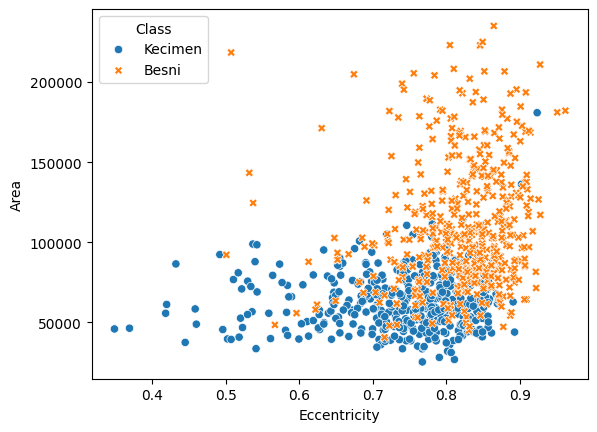

In [ ]:
sns.scatterplot(x='Eccentricity', y='Area', hue='Class', data=raisin_data, style='Class');

In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in raisin_data[['Class']]:
  raisin_data[col] = LabelEncoder().fit_transform(raisin_data[col])

In [ ]:
from sklearn.preprocessing import StandardScaler

for col in raisin_data[['Area','MajorAxisLength','MinorAxisLength','Eccentricity','ConvexArea','Extent','Perimeter']]:
  raisin_data[col] = StandardScaler().fit_transform(raisin_data[[col]])

In [ ]:
from sklearn.decomposition import PCA

X = raisin_data.drop('Class',axis=1)
Y = raisin_data['Class']

PCA_TR = PCA(n_components=3)
X_train = PCA_TR.fit_transform(X)

In [ ]:
PCA_TR.explained_variance_ratio_

array([0.69032694, 0.20759835, 0.0897785 ])

In [ ]:
PCA_TR.components_

array([[ 0.44828422,  0.4432398 ,  0.38938118,  0.20297098,  0.45093833,
        -0.05636836,  0.45082374],
       [ 0.11609991, -0.13658724,  0.37492246, -0.61082321,  0.08761633,
         0.66734439, -0.03417227],
       [-0.00548378,  0.10054797, -0.23604354,  0.62852206, -0.0366724 ,
         0.73198093, -0.04430077]])

In [ ]:
from sklearn.model_selection import StratifiedKFold,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

LRM = LogisticRegression()
DTC = DecisionTreeClassifier()
RFC = RandomForestClassifier()
KNC = KNeighborsClassifier()
NBC = GaussianNB()

SKF = StratifiedKFold(n_splits = 10, shuffle =True, random_state=10)

print(f'LogisticRegression : {round(cross_val_score(LRM,X_train,Y,cv=SKF,scoring="accuracy").mean()*100,2)}%')
print(f'DecisionTreeClassifier : {round(cross_val_score(DTC,X_train,Y,cv=SKF,scoring="accuracy").mean()*100,2)}%')
print(f'RandomForestClassifier : {round(cross_val_score(RFC,X_train,Y,cv=SKF,scoring="accuracy").mean()*100,2)}%')
print(f'KNeighborsClassifier : {round(cross_val_score(KNC,X_train,Y,cv=SKF,scoring="accuracy").mean()*100,2)}%')
print(f'GaussianNB : {round(cross_val_score(NBC,X_train,Y,cv=SKF,scoring="accuracy").mean()*100,2)}%')

LogisticRegression : 86.33%
DecisionTreeClassifier : 80.44%
RandomForestClassifier : 84.89%
KNeighborsClassifier : 84.56%
GaussianNB : 84.22%
